In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Krish Naik AIML/KN_Deep_Learning/Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
dataset.shape

(10000, 14)

In [6]:
## Dividing the dataset into dependent and independent features
X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [7]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [8]:
## Feature Engineering
geography = pd.get_dummies(X['Geography'], drop_first=True).astype(int)
gender = pd.get_dummies(X['Gender'], drop_first=True).astype(int)

In [9]:
X = X.drop(['Gender', 'Geography'], axis = 1)

In [10]:
X = pd.concat([X, geography, gender], axis = 1)

In [11]:
## Splitting the data into train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [12]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [13]:
X_train, X_test

(array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
          1.74309049, -1.09168714],
        [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
         -0.57369368,  0.91601335],
        [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
         -0.57369368, -1.09168714],
        ...,
        [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
         -0.57369368,  0.91601335],
        [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
          1.74309049, -1.09168714],
        [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
         -0.57369368, -1.09168714]]),
 array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
         -0.57369368, -1.09168714],
        [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
         -0.57369368, -1.09168714],
        [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
          1.74309049, -1.09168714],
        ...,
        [-0.74791227, -0.27319958, -1.37744033, ..., -

In [14]:
X_train.shape

(8000, 11)

In [15]:
## Creating ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [16]:
classifier = Sequential()

In [17]:
#Adding the input layer
classifier.add(Dense(units = 11, activation = 'relu'))

In [18]:
#Adding the first hidden layer
classifier.add(Dense(units = 7, activation = 'relu'))
#Adding the second hidden layer
classifier.add(Dense(units = 6, activation = 'relu'))
#Adding the output layer
classifier.add(Dense(units = 1, activation = 'sigmoid'))

In [19]:
import tensorflow as tf
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

In [20]:
classifier.compile(optimizer = opt, loss = 'binary_crossentropy', metrics = ['accuracy'])

In [21]:
model_history = classifier.fit(X_train, y_train, validation_split = 0.33, batch_size = 10, epochs = 30)

Epoch 1/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7692 - loss: 0.4926 - val_accuracy: 0.8243 - val_loss: 0.4199
Epoch 2/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8198 - loss: 0.4248 - val_accuracy: 0.8444 - val_loss: 0.3644
Epoch 3/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8597 - loss: 0.3434 - val_accuracy: 0.8501 - val_loss: 0.3640
Epoch 4/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8630 - loss: 0.3377 - val_accuracy: 0.8448 - val_loss: 0.3630
Epoch 5/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8556 - loss: 0.3449 - val_accuracy: 0.8501 - val_loss: 0.3544
Epoch 6/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8651 - loss: 0.3355 - val_accuracy: 0.8527 - val_loss: 0.3601
Epoch 7/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8595 - loss: 0.3375 - val_accuracy: 0.8523 - val_loss: 0.3540
Epoch 8/30
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8570 - loss: 0.3482 - val_accuracy: 

In [22]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

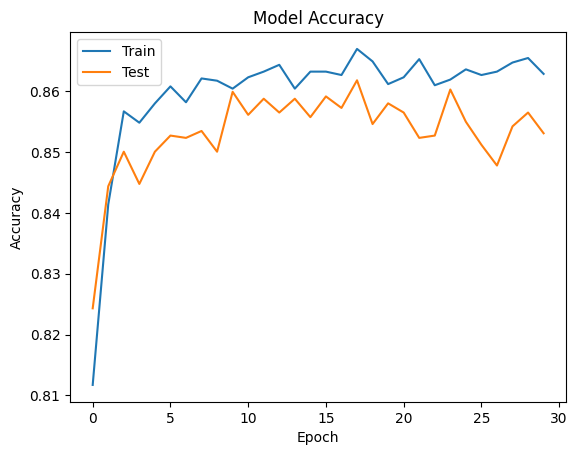

In [23]:
#Plotting history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'upper left')
plt.show()

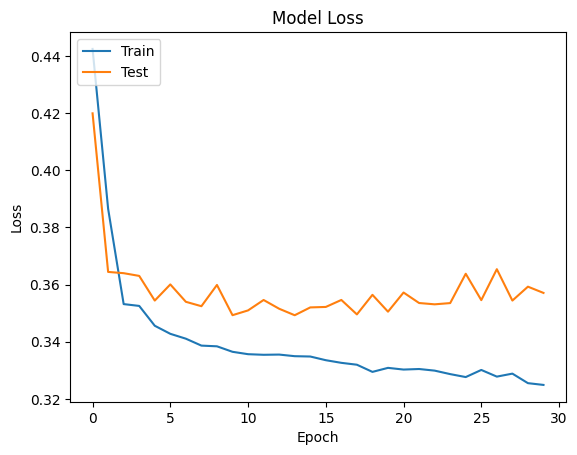

In [24]:
#Plotting history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'upper left')
plt.show()

In [25]:
# Making predictions on the test data
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [26]:
# Confusion Matrix
y_test = (y_test >= 0.5)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1531,   64],
       [ 208,  197]])

In [27]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.864

In [28]:
#Getting the weights
classifier.get_weights()

[array([[-1.29983470e-01,  6.52963161e-01,  4.13460545e-02,
         -7.49093652e-01,  9.58804131e-01, -4.44346547e-01,
          1.17199607e-01,  2.59680271e-01,  3.11839394e-02,
          9.59112272e-02,  1.22127309e-01],
        [ 4.75896955e-01, -1.32812488e+00,  2.82299376e+00,
         -1.71838903e+00, -1.06200278e+00, -2.94000894e-01,
          2.18065715e+00, -8.46421361e-01,  1.51365578e-01,
         -2.90745318e-01, -3.20121551e+00],
        [-2.16763914e-02, -6.63955286e-02, -3.99844915e-01,
          1.26662850e+00, -1.88209474e-01, -1.26644051e+00,
         -8.22877064e-02,  7.38498032e-01,  1.46181926e-01,
          4.10999805e-01, -8.51161301e-01],
        [ 3.96735430e-01, -1.00194478e+00, -4.60659675e-02,
         -1.77157593e+00, -1.59932137e+00, -2.34784067e-01,
         -1.03598821e+00, -1.49153426e-01, -2.92402196e+00,
         -2.36656368e-01, -1.06897449e+00],
        [ 3.07124996e+00, -1.25288689e+00, -1.13226199e+00,
          1.62668690e-01,  1.08497667e+00, -